In [ ]:
# open sep2012 run to investigate wvel rms

from xmitgcm import open_mdsdataset
data_dir = '/data/SO3/edavenport/tpose6/sep2012/run_iter24/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

prefix = 'diag_state'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

ds['XC'] = ds.XC.astype(float)
ds['YC'] = ds.YC.astype(float)
ds['Z'] = ds.Z.astype(float)
ds['XG'] = ds.XG.astype(float)
ds['YG'] = ds.YG.astype(float)
ds['Zl'] = ds.Zl.astype(float)

In [6]:
# rms of wvel at 50m depth
import numpy as np
wvel_rms = np.sqrt((ds.WVEL.isel(Zl=15)**2).mean(dim='time'))

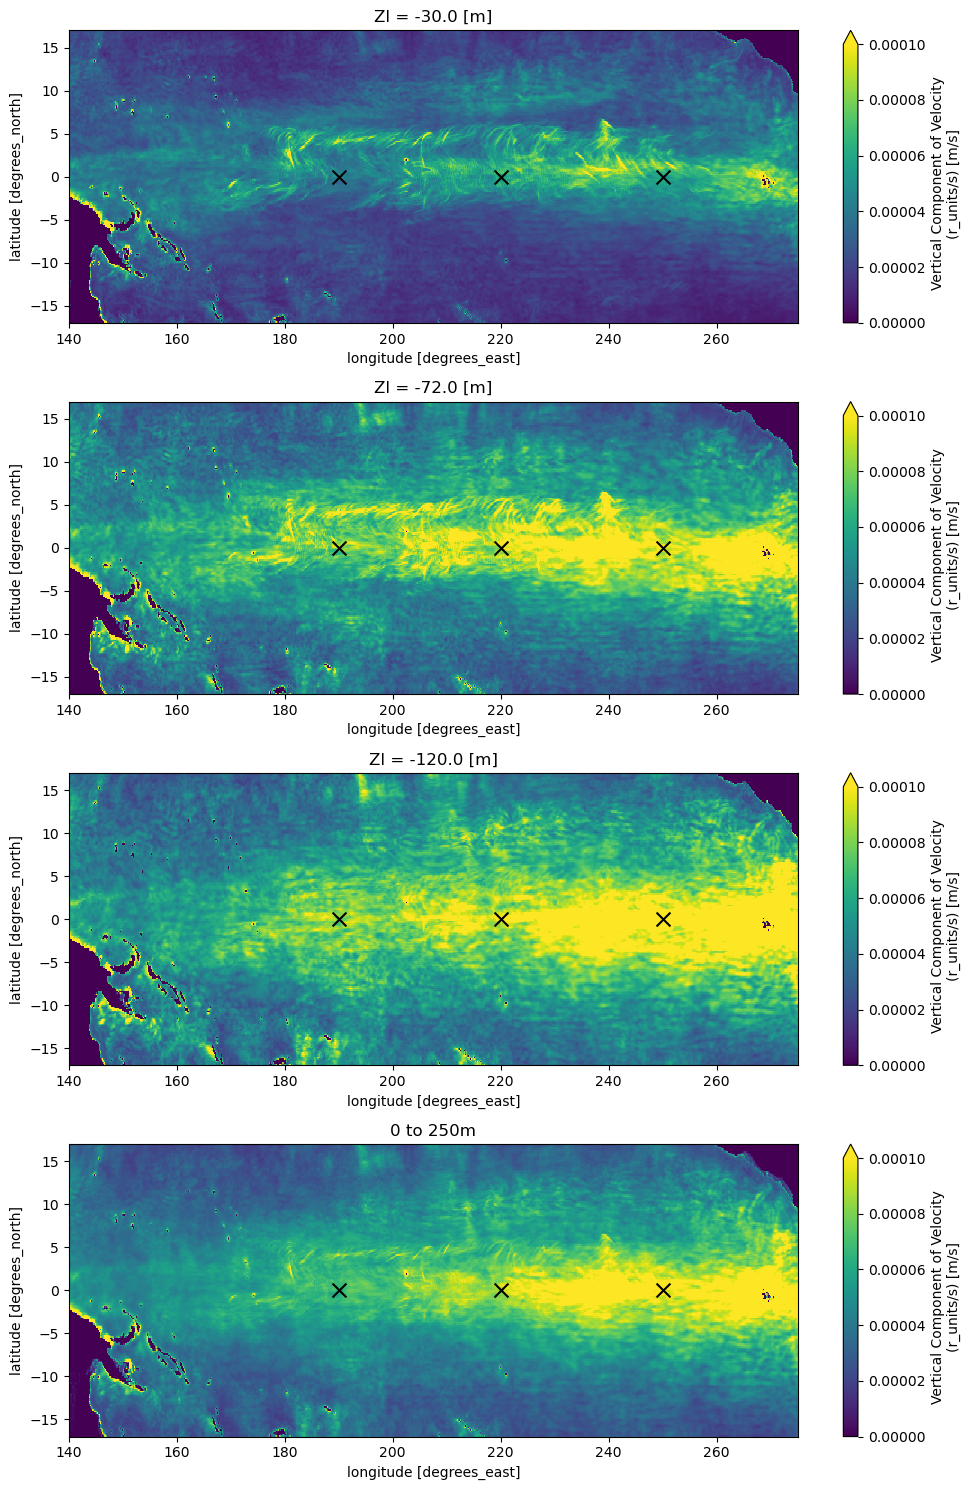

In [27]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,15),nrows=4)
wvel_rms = np.sqrt((ds.WVEL.sel(Zl=-30,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[0],vmin=0,vmax=0.0001)
# scatter plot of moorings at 0N, 190E, 0N, 220E, and 0N, 250E
moorings = [(0,190),(0,220),(0,250)]
for lat,lon in moorings:
    ax[0].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.WVEL.sel(Zl=-70,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[1],vmin=0,vmax=0.0001)
for lat,lon in moorings:
    ax[1].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.WVEL.sel(Zl=-120,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[2],vmin=0,vmax=0.0001)
for lat,lon in moorings:
    ax[2].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.WVEL.sel(Zl=slice(0,-250))**2).mean(dim=['time','Zl']))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[3],vmin=0,vmax=0.0001)
for lat,lon in moorings:
    ax[3].scatter(lon,lat,color='k',marker='x',s=100)
ax[3].set_title("0 to 250m")

plt.tight_layout()
fig.savefig('assimilation_controls/shortwave_rad_xx/wvel_rms.png',dpi=300)